# Γιάννης Φίλλης ΑΜ:5380, Κωνσταντίνος Ζώης ΑΜ:5226

# Ερώτημα 4

Το πρώτο που θα κάνουμε είναι να φορτώσουμε τα δεδομένα και έπειτα θα δημιουργήσουμε πάλι το sparse matrix R user x movie.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_train = pd.read_csv("data_train.csv")
df_test = pd.read_csv("data_test.csv")

In [3]:
from scipy.sparse import csr_matrix
from scipy.sparse import coo_matrix

R = coo_matrix((df_train['rating'], (df_train['uid'], df_train['mid']))).tocsr()

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(R)

In [5]:
similarity_matrix

array([[1.        , 0.        , 0.        , ..., 0.07290656, 0.        ,
        0.01943687],
       [0.        , 1.        , 0.08196459, ..., 0.02846385, 0.16521604,
        0.1011794 ],
       [0.        , 0.08196459, 1.        , ..., 0.09645414, 0.10854304,
        0.15255433],
       ...,
       [0.07290656, 0.02846385, 0.09645414, ..., 1.        , 0.04754552,
        0.0445493 ],
       [0.        , 0.16521604, 0.10854304, ..., 0.04754552, 1.        ,
        0.18647251],
       [0.01943687, 0.1011794 , 0.15255433, ..., 0.0445493 , 0.18647251,
        1.        ]])

Παρακάτω υλοποιούμε την συνάρτηση που θα έχουμε για την πρόβλεψη. Αρχικά, δημιουργούμε την συνάρτηση **create network** η οποία παίρνει σαν παράμετρο το m και δημιουργεί το δίκτυο μας.

In [6]:
import networkx as nx

In [7]:
def create_network(m):
    top_m_users = []
    for u in range(similarity_matrix.shape[0]):
        similarity_matrix[u,u] = 0 #to midenizoume gia na min pernoume thn omoiotita me ton eayto tou
        top_users_of_u = np.argsort(similarity_matrix[u])[-m:]
        top_m_users.append(top_users_of_u)
    top_m_users = np.array(top_m_users)
    G = nx.Graph()
    total_users = R.shape[0]
    for u in range(total_users):
        for v in top_m_users[u]:
            if not G.has_edge(u, v): # check if it doesnt exist
                weight = similarity_matrix[u,v]
                G.add_edge(u,v,weight = weight)
    return G


Η συνάρτηση **compute_ppr** παίρνει σαν παράμετρο το δίκτυο **G** που δημιουργούμε με την παραπάνω συνάρτηση καθώς και την τιμή alpha που την ορίζουμε στην default τιμή 0.85 (ώστε η restart probability = 0.15) και υπολογίζει τα **ppr_scores** με την συνάρτηση **pagerank**.

In [8]:
def compute_ppr(G, alpha=0.85):
    ppr_scores = {}
    for u in G.nodes:
        ppr = nx.pagerank(G, alpha=alpha, personalization={u:1})
        ppr_scores[u] = ppr
    return ppr_scores

Η παρακάτω συνάρτηση είναι και η τελική, δηλαδή αυτή που εφαρμόζει τον τελικό αλγόριθμο παρόμοια με την 2η άσκηση. Αρχικά παίρνει τα **ppr_scores** των top k, και έπειτα παίρνει τα indexes αυτών που βαθμολογήσαν.  
Επειτα υπολογίζει τα ppr αυτών που βαθμολογήσαν και υπολογίζει τον αριθμητή και παρονομαστή της εξίσωσης p(u,m) για την πρόβλεψη όπως δίνεται στην 2η άσκηση, με τη διαφορά ότι τώρα τα similarities είναι τα PPR scores. Υλοποιούμε την αργή εκδοχή του αλγορίθμου.

In [9]:
def user_mean(R,u):
    row = R.getrow(u)
    return row.data.mean()

In [10]:
def item_users(R,m):
    col = R[:, m]
    rows, column = col.nonzero()
    return rows

In [11]:
def predict_rating(u, item, R, ppr_scores,k):
    users_rated = item_users(R,item)

    if (len(users_rated) == 0):
        return user_mean(R,u)

    ppr = np.array([ppr_scores[u].get(v, 0) for v in users_rated])
    if ppr.size == 0 or np.all(ppr == 0):
      return 0.0

    # k most similar
    idx = np.argsort(-ppr)[:k]
    neighbors = users_rated[idx]
    ppr = ppr[idx]
    ratings = np.array([R[v, item] for v in neighbors])
    numerator = np.dot(ppr, ratings)
    denominator = np.sum(ppr)

    if denominator == 0:
        return 0
    return numerator/denominator

Στη συνέχεια τρέχουμε τον αγόριθμο για κάθε τιμή του k και m.

In [12]:
from sklearn.metrics import root_mean_squared_error

k_values = [1,2,3,5,10,20,30,40,50,60,70,80,90,100]
m_values = [3,5,10]
rmse_results = {}

for m in m_values:
    print("Running for m=",m)
    G = create_network(m)
    ppr_scores = compute_ppr(G, alpha=0.85)

    rmse_list = []
    for k_val in k_values:
        predictions = []
        for uid, mid in zip(df_test.uid.values, df_test.mid.values):
            pred = predict_rating(int(uid), int(mid), R, ppr_scores, k_val)
            predictions.append(pred)
        predictions = np.array(predictions)
        predictions = np.clip(predictions, 0, 5)
        rmse_value = root_mean_squared_error(df_test.rating.values, predictions)
        rmse_list.append(rmse_value)
    rmse_results[m] = rmse_list

Running for m= 3
Running for m= 5
Running for m= 10


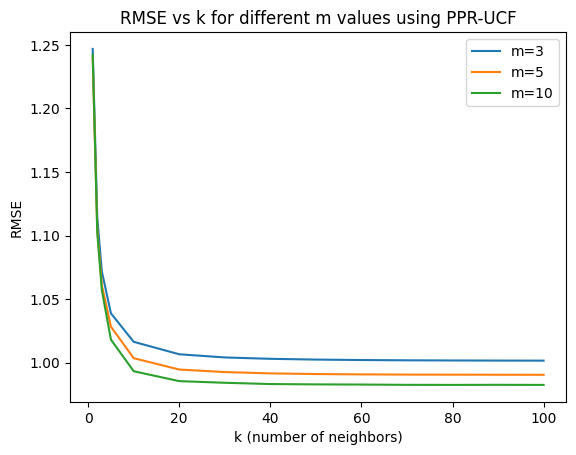

In [13]:
import matplotlib.pyplot as plt

for m in m_values:
    plt.plot(k_values, rmse_results[m], label=f'm={m}')
plt.xlabel("k (number of neighbors)")
plt.ylabel("RMSE")
plt.title("RMSE vs k for different m values using PPR-UCF")
plt.legend()
plt.show()

In [14]:
print(min(rmse_results[10]))
print(rmse_results)

0.9825604761274239
{3: [1.2468235018566498, 1.1143369345590595, 1.0718964645341351, 1.0388897714432315, 1.0164655678811556, 1.006673871769961, 1.0041717387102522, 1.0030871103118755, 1.0024886359840608, 1.0021395019386496, 1.0019147862441218, 1.001799331829166, 1.001710987462432, 1.001651674742154], 5: [1.2395034670310845, 1.1050944342966047, 1.061098904550454, 1.0283420788928377, 1.0035824341407888, 0.9946642310286926, 0.9926731515409104, 0.9916323570527488, 0.991114156196473, 0.9908398928179213, 0.9906898201172708, 0.9906174043326534, 0.9905735114068829, 0.9905049824501744], 10: [1.2421931592075683, 1.1027025150970684, 1.0572249848251312, 1.0182136898367908, 0.9933250818884862, 0.9855435109966771, 0.9842438643516982, 0.9832543736791103, 0.9829866526471962, 0.9828493883559636, 0.9826277492304096, 0.9825695482844039, 0.9826357841246577, 0.9825604761274239]}


Παρατηρούμε ότι το χαμηλότερο rmse είναι ίσο περίπου με 0.98 και επιτυχγάνεται για m=10 και k=100. Στον κλασικό αλγόριθμο UCF στην προηγούμενη άσκηση είχαμε βρει ελαφρώς χαμηλότερο σφάλμα ίσο με 0.97 για k=30. Επομένως ο αλγόριθμος δουλεύει καλύτερα όσο περισσότερες ακμές (όμοιους χρήστες) προσθέτουμε σε κάθε κόμβο χρήστη.

## Bonus

Σε αυτό το σημείο δοκιμάζουμε τον αλγόριθμο για περισσότερες τιμές του restart propability. Θέτουμε επιπλέον τις τιμές 0.1, 0.3, 0.5, 0.95 για το **alpha**.

In [15]:
m_values = [3, 5, 10]
alpha_values = [0.1, 0.3, 0.5, 0.95]
k_values = [1,2,3,5,10,20,30,40,50,60,70,80,90,100]

rmse_results_b = {}

for m in m_values:
    print(f"Running for m = {m}")
    G = create_network(m)
    for alpha in alpha_values:
        print(f"  Running for alpha = {alpha}")
        ppr_scores = compute_ppr(G, alpha=alpha)
        rmse_list = []

        for k_val in k_values:
            predictions = []
            for uid, mid in zip(df_test.uid.values, df_test.mid.values):
                pred = predict_rating(int(uid), int(mid), R, ppr_scores, k_val)
                predictions.append(pred)

            predictions = np.array(predictions)
            predictions = np.clip(predictions, 0, 5)
            rmse_value = root_mean_squared_error(df_test.rating.values, predictions)
            rmse_list.append(rmse_value)

        rmse_results_b[(m, alpha)] = rmse_list


Running for m = 3
  Running for alpha = 0.1
  Running for alpha = 0.3
  Running for alpha = 0.5
  Running for alpha = 0.95
Running for m = 5
  Running for alpha = 0.1
  Running for alpha = 0.3
  Running for alpha = 0.5
  Running for alpha = 0.95
Running for m = 10
  Running for alpha = 0.1
  Running for alpha = 0.3
  Running for alpha = 0.5
  Running for alpha = 0.95


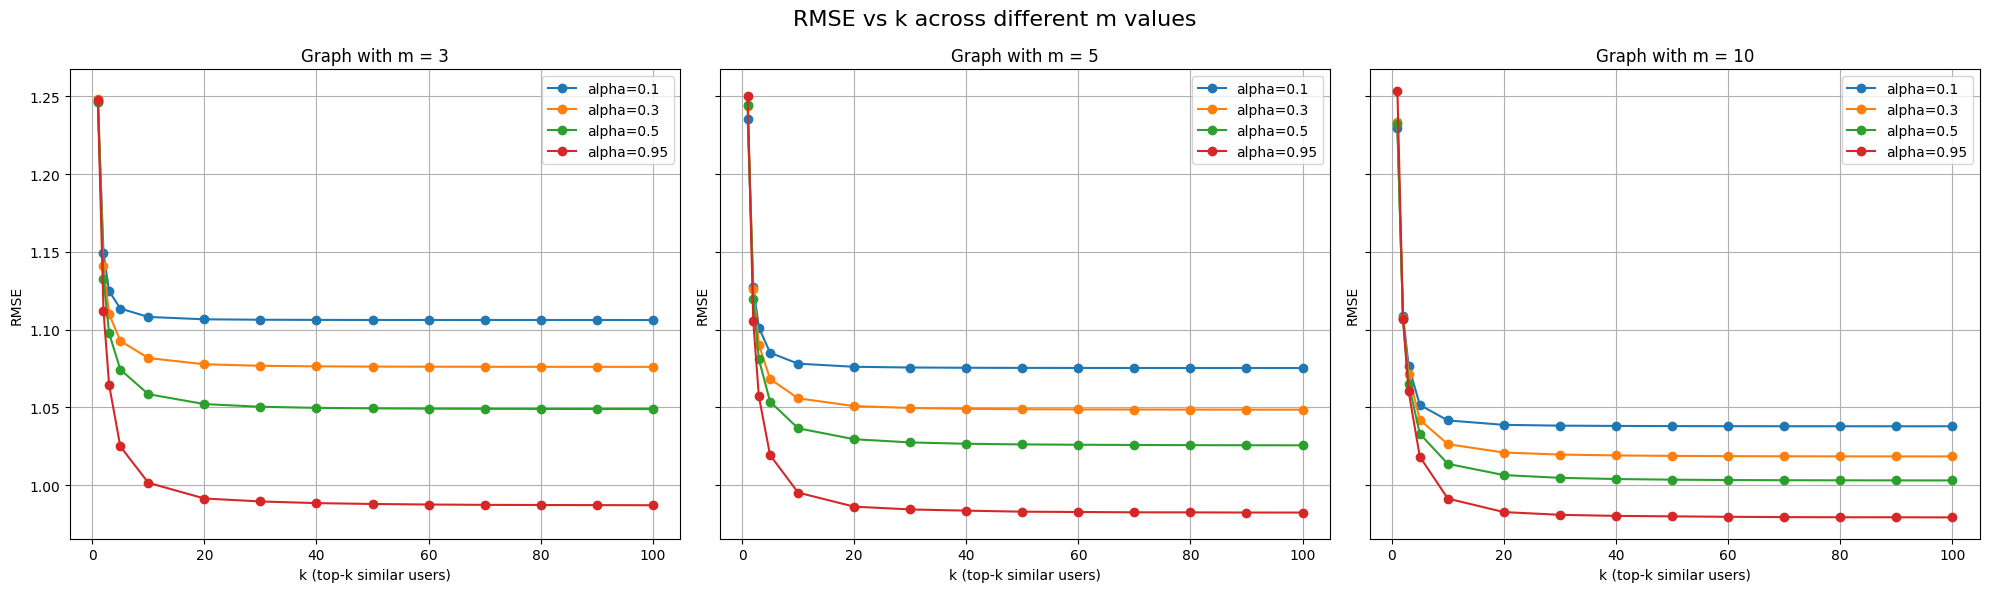

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(nrows=1, ncols=len(m_values), figsize=(20, 6), sharey=True)

for idx, m in enumerate(m_values):
    ax = axes[idx] 
    
    for alpha in alpha_values:
        rmse_list = rmse_results_b[(m, alpha)]
        ax.plot(k_values, rmse_list, marker='o', label=f'alpha={alpha}')
    
    ax.set_title(f'Graph with m = {m}')
    ax.set_xlabel('k (top-k similar users)')
    ax.grid(True)
    ax.legend()

axes[0].set_ylabel('RMSE')
axes[1].set_ylabel('RMSE')
axes[2].set_ylabel('RMSE')

plt.suptitle('RMSE vs k across different m values', fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
print(min(rmse_results_b[10,0.95]))
print((rmse_results_b[10,0.95]))

0.979353267750004
[1.2536920853152416, 1.1067136296802145, 1.060320469257213, 1.018351577153782, 0.9914327107685149, 0.982765306752429, 0.9810059368205601, 0.9803100333376988, 0.9800261575504642, 0.9797183236371426, 0.9795433926032155, 0.9794356654008061, 0.9794235129492894, 0.979353267750004]


Από το γράφημα παρατηρούμε ότι το χειρότερο σφάλμα εμφανίζεται για m=3, a=0.1. Σφάλμα μικρότερο από 1 πετυχαίνουμε με τους συνδυασμούς (m=10, alpha=0.95), (m=5, alpha=0.95) και (m=3, alpha=0.95). Για την μικρότερη τιμή του **restart probability** λοιπόν ο αλγόριθμος φαίνεται να δουλεύει καλύτερα ανεξάρτητα του m. Το χαμηλότερο **RMSE** είναι για (m=10, alpha=0.95, k=100) ίσο με 0.979 ~= 0.98 ελάχιστα μικρότερο από αυτό που βρήκαμε πριν με alpha=0.85 (0.982).  
Άρα μπορούμε να κάνουμε την παρατήρηση πως για δεδομένο m μειώνοντας το **restart probability** (άρα αυξάνοντας το alpha) μειώνεται και το **RMSE**, ενώ για δεδομένο alpha φαίνεται το **RMSE** να είναι μικρότερο όσο αυξάνεται το m.